# NEWAVE Toy — PDDE Didática

**Implementação simplificada da Programação Dinâmica Dual Estocástica (PDDE)**

Sistema:
- 1 UHE (Usina Hidrelétrica)
- 2 UTEs (Usinas Termelétricas)
- 3 estágios mensais
- 2 aberturas (cenários) no Forward
- 3 aberturas no Backward

Objetivo: entender passo a passo o funcionamento do Forward, Backward, construção de cortes e o papel das **variáveis duais**.

## 1. Configuração do Sistema

In [ ]:
import numpy as np
from scipy.optimize import linprog
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
np.set_printoptions(precision=2, suppress=True)

In [2]:
@dataclass
class UHE:
    """Usina Hidrelétrica."""
    nome: str
    v_min: float        # Volume mínimo (MWmês)
    v_max: float        # Volume máximo (MWmês)
    v_ini: float        # Volume inicial (MWmês)
    q_max: float        # Turbinamento máximo (MWmed)
    produtibilidade: float = 1.0  # Simplificação: 1 m³/s ≈ 1 MWmed

@dataclass
class UTE:
    """Usina Termelétrica."""
    nome: str
    gt_max: float       # Capacidade máxima (MWmed)
    custo: float        # Custo variável (R$/MWh)

@dataclass
class Corte:
    """Corte de Benders: alpha >= pi * v + delta."""
    pi: float           # Coeficiente (valor da água)
    delta: float        # Termo independente

In [3]:
# ── Dados do Sistema ──────────────────────────────────────────────

uhe = UHE(
    nome="UHE Toy",
    v_min=20.0,     # 20 MWmês
    v_max=100.0,    # 100 MWmês
    v_ini=80.0,     # Começa com 80% do máximo
    q_max=50.0,     # Pode turbinar até 50 MWmed
)

utes = [
    UTE(nome="UTE Barata",  gt_max=30.0, custo=80.0),   # R$ 80/MWh
    UTE(nome="UTE Cara",    gt_max=40.0, custo=200.0),  # R$ 200/MWh
]

CUSTO_DEFICIT = 5000.0   # R$/MWh (penalidade por não atendimento)

# Demanda mensal (MWmed) — crescente
demanda = [60.0, 70.0, 65.0]  # 3 estágios

# Afluências médias por estágio (MWmês)
afluencia_media = [40.0, 30.0, 35.0]

# Desvio padrão dos ruídos (para gerar cenários)
desvio_ruido = [10.0, 12.0, 8.0]

N_ESTAGIOS = 3
N_FORWARD = 2    # Séries forward
N_BACKWARD = 3   # Aberturas backward
MAX_ITER = 15    # Iterações máximas

print("Sistema configurado:")
print(f"  UHE: {uhe.nome} | Vmin={uhe.v_min} | Vmax={uhe.v_max} | Vini={uhe.v_ini} | Qmax={uhe.q_max}")
for u in utes:
    print(f"  UTE: {u.nome} | GTmax={u.gt_max} | Custo={u.custo} R$/MWh")
print(f"  Déficit: {CUSTO_DEFICIT} R$/MWh")
print(f"  Demanda: {demanda}")
print(f"  Afluência média: {afluencia_media}")

Sistema configurado:
  UHE: UHE Toy | Vmin=20.0 | Vmax=100.0 | Vini=80.0 | Qmax=50.0
  UTE: UTE Barata | GTmax=30.0 | Custo=80.0 R$/MWh
  UTE: UTE Cara | GTmax=40.0 | Custo=200.0 R$/MWh
  Déficit: 5000.0 R$/MWh
  Demanda: [60.0, 70.0, 65.0]
  Afluência média: [40.0, 30.0, 35.0]


## 2. O Subproblema de Cada Estágio (PL)

Variáveis de decisão (nesta ordem):
- `q` — turbinamento (MWmed)
- `s` — vertimento (MWmês)
- `gt1` — geração UTE 1 (MWmed)
- `gt2` — geração UTE 2 (MWmed)
- `def_` — déficit (MWmed)
- `v` — volume final (MWmês)
- `alpha` — custo futuro

Total: 7 variáveis

### Função Objetivo
```
min  0·q + 0·s + 80·gt1 + 200·gt2 + 5000·def + 0·v + 1·alpha
```

### Restrições (igualdade)
1. **Balanço hídrico:** `v = v_ant + afluencia - q - s`
   → `q + s + v = v_ant + afluencia`  (dual: **π_agua** — valor da água)

2. **Atendimento à demanda:** `q + gt1 + gt2 + def = D`
   (dual: **π_demanda** — CMO)

### Limites
- 0 ≤ q ≤ q_max
- 0 ≤ s
- 0 ≤ gt1 ≤ gt1_max
- 0 ≤ gt2 ≤ gt2_max
- 0 ≤ def
- v_min ≤ v ≤ v_max
- 0 ≤ alpha (sem limite superior se há cortes; se não há, alpha = 0)

In [4]:
def resolver_estagio(v_ant, afluencia, t, cortes_futuro, verbose=False):
    """
    Resolve o PL de um estágio.

    Retorna:
        resultado (dict): decisões ótimas, custo, e VARIÁVEIS DUAIS
    """
    # Variáveis: q, s, gt1, gt2, def, v, alpha
    #            0  1   2    3    4   5    6

    # ── Função objetivo ──
    c = [
        0.0,              # q: custo zero (hidro é "grátis")
        0.0,              # s: vertimento sem custo
        utes[0].custo,    # gt1: 80 R$/MWh
        utes[1].custo,    # gt2: 200 R$/MWh
        CUSTO_DEFICIT,    # def: 5000 R$/MWh
        0.0,              # v: volume final, sem custo direto
        1.0,              # alpha: custo futuro
    ]

    # ── Restrições de igualdade (A_eq @ x = b_eq) ──
    # Restrição 1: Balanço hídrico
    #   q + s + v = v_ant + afluencia
    #   [1, 1, 0, 0, 0, 1, 0]

    # Restrição 2: Atendimento à demanda
    #   q + gt1 + gt2 + def = D(t)
    #   [1, 0, 1, 1, 1, 0, 0]

    A_eq = [
        [1, 1, 0, 0, 0, 1, 0],  # Balanço hídrico
        [1, 0, 1, 1, 1, 0, 0],  # Demanda
    ]
    b_eq = [
        v_ant + afluencia,       # RHS balanço hídrico
        demanda[t],              # RHS demanda
    ]

    # ── Cortes de Benders (restrições de desigualdade) ──
    # alpha >= pi_k * v + delta_k
    # Reescrevendo: pi_k * v - alpha <= -delta_k
    # Em forma A_ub @ x <= b_ub:
    #   [0, 0, 0, 0, 0, pi_k, -1] <= -delta_k

    A_ub = []
    b_ub = []
    for corte in cortes_futuro:
        row = [0, 0, 0, 0, 0, corte.pi, -1]  # pi*v - alpha <= -delta
        A_ub.append(row)
        b_ub.append(-corte.delta)

    # ── Limites das variáveis ──
    bounds = [
        (0, uhe.q_max),         # q
        (0, None),              # s (vertimento, sem limite superior)
        (0, utes[0].gt_max),    # gt1
        (0, utes[1].gt_max),    # gt2
        (0, None),              # def
        (uhe.v_min, uhe.v_max), # v
        (0, None),              # alpha (custo futuro >= 0)
    ]

    # Se último estágio, alpha = 0 (sem futuro)
    if t == N_ESTAGIOS - 1:
        bounds[6] = (0, 0)

    # ── Resolver ──
    res = linprog(
        c,
        A_ub=A_ub if A_ub else None,
        b_ub=b_ub if b_ub else None,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method='highs'
    )

    if not res.success:
        raise ValueError(f"PL infactível no estágio {t+1}! Status: {res.message}")

    x = res.x

    # ── Extrair variáveis duais ──
    # Para linprog/HiGHS, as duais das restrições de igualdade estão em:
    # res.eqlin.marginals (com sinal conforme a formulação)
    pi_agua = -res.eqlin.marginals[0]     # Dual do balanço hídrico
    pi_demanda = -res.eqlin.marginals[1]  # Dual do atendimento à demanda (CMO)

    resultado = {
        'q': x[0],
        's': x[1],
        'gt1': x[2],
        'gt2': x[3],
        'deficit': x[4],
        'v_final': x[5],
        'alpha': x[6],
        'custo_imediato': utes[0].custo * x[2] + utes[1].custo * x[3] + CUSTO_DEFICIT * x[4],
        'custo_total': res.fun,
        'pi_agua': pi_agua,
        'pi_demanda': pi_demanda,
    }

    if verbose:
        print(f"    Estágio {t+1}: q={x[0]:.1f} | s={x[1]:.1f} | "
              f"gt1={x[2]:.1f} | gt2={x[3]:.1f} | def={x[4]:.1f} | "
              f"v_final={x[5]:.1f} | alpha={x[6]:.1f}")
        print(f"             Custo imediato={resultado['custo_imediato']:.1f} | "
              f"π_água={pi_agua:.2f} | π_demanda(CMO)={pi_demanda:.2f}")

    return resultado

## 3. Geração de Afluências (Ruídos)

Simplificação: usamos modelo `ENA(t) = média(t) + ε(t)`, onde `ε ~ N(0, σ²)`, truncado para garantir afluência positiva.

In [5]:
def gerar_afluencias(t, n_cenarios):
    """
    Gera n cenários de afluência para o estágio t.
    ENA(t) = média(t) + ruído, com ruído ~ N(0, σ²), truncado em 5.
    """
    ruidos = np.random.normal(0, desvio_ruido[t], size=n_cenarios)
    afluencias = afluencia_media[t] + ruidos
    afluencias = np.maximum(afluencias, 5.0)  # Afluência mínima de 5 MWmês
    return afluencias

# Demonstração
print("Exemplos de afluências geradas:")
for t in range(N_ESTAGIOS):
    afl = gerar_afluencias(t, 5)
    print(f"  Estágio {t+1}: média={afluencia_media[t]:.0f}, "
          f"cenários={np.round(afl, 1)}")

Exemplos de afluências geradas:
  Estágio 1: média=40, cenários=[45.  38.6 46.5 55.2 37.7]
  Estágio 2: média=30, cenários=[27.2 49.  39.2 24.4 36.5]
  Estágio 3: média=35, cenários=[31.3 31.3 36.9 19.7 21.2]


## 4. Algoritmo PDDE Completo

Agora implementamos o loop principal:
1. **Forward**: simula `N_FORWARD=2` séries do estágio 1 ao 3
2. **Backward**: do estágio 2 ao 1, cria cortes com `N_BACKWARD=3` aberturas
3. **Convergência**: compara Z_inf com Z_sup

In [6]:
def pdde(verbose=True):
    """
    Executa o algoritmo PDDE completo.

    Retorna:
        cortes: lista de cortes por estágio
        historico: histórico de Zinf e Zsup
    """
    # Cortes por estágio: cortes[t] são os cortes da FCF do estágio t
    # cortes[t] são usados no PL do estágio t para representar o futuro
    cortes = [[] for _ in range(N_ESTAGIOS)]

    historico = {'zinf': [], 'zsup': [], 'duais': []}

    for iteracao in range(1, MAX_ITER + 1):
        if verbose:
            print(f"\n{'='*70}")
            print(f"  ITERAÇÃO {iteracao}")
            print(f"{'='*70}")

        # ══════════════════════════════════════════════════════════════
        # FORWARD
        # ══════════════════════════════════════════════════════════════
        if verbose:
            print(f"\n  ── FORWARD (t=1→{N_ESTAGIOS}, {N_FORWARD} séries) ──")

        # Armazenar estados visitados e custos
        volumes_forward = np.zeros((N_FORWARD, N_ESTAGIOS))   # v_final por série/estágio
        custos_forward = np.zeros(N_FORWARD)                  # custo total por série
        afluencias_forward = np.zeros((N_FORWARD, N_ESTAGIOS))
        duais_forward = np.zeros((N_FORWARD, N_ESTAGIOS, 2))  # pi_agua, pi_demanda

        for serie in range(N_FORWARD):
            if verbose:
                print(f"\n  Série Forward {serie+1}:")

            v_atual = uhe.v_ini
            custo_acum = 0.0

            for t in range(N_ESTAGIOS):
                # Gerar afluência (ruído forward)
                afl = gerar_afluencias(t, 1)[0]
                afluencias_forward[serie, t] = afl

                # Resolver PL com cortes do estágio t (representam futuro de t)
                res = resolver_estagio(
                    v_ant=v_atual,
                    afluencia=afl,
                    t=t,
                    cortes_futuro=cortes[t],
                    verbose=verbose
                )

                volumes_forward[serie, t] = res['v_final']
                custo_acum += res['custo_imediato']
                duais_forward[serie, t] = [res['pi_agua'], res['pi_demanda']]
                v_atual = res['v_final']

            custos_forward[serie] = custo_acum
            if verbose:
                print(f"    → Custo total série {serie+1}: {custo_acum:.1f} R$")

        # Limite superior
        zsup = np.mean(custos_forward)
        zsup_std = np.std(custos_forward) / np.sqrt(N_FORWARD) if N_FORWARD > 1 else 0

        if verbose:
            print(f"\n  Z_sup (média forward) = {zsup:.1f} ± {1.96*zsup_std:.1f}")

        # ══════════════════════════════════════════════════════════════
        # BACKWARD
        # ══════════════════════════════════════════════════════════════
        if verbose:
            print(f"\n  ── BACKWARD (t={N_ESTAGIOS-1}→1, {N_BACKWARD} aberturas) ──")

        duais_backward = []

        for t in range(N_ESTAGIOS - 2, -1, -1):
            # Percorre de t=1 (índice 1) até t=0 (índice 0)
            if verbose:
                print(f"\n  Construindo cortes para estágio {t+1} "
                      f"(resolvendo estágio {t+2}):")

            # Para cada estado visitado no forward
            for serie in range(N_FORWARD):
                if t == 0:
                    v_visitado = uhe.v_ini  # Para o estágio 1, estado é o volume inicial
                else:
                    v_visitado = volumes_forward[serie, t - 1]

                # Gerar aberturas backward (ruídos independentes do forward)
                afl_backward = gerar_afluencias(t + 1, N_BACKWARD)  # Afluência do estágio t+1

                if verbose:
                    print(f"\n    Estado v={v_visitado:.1f} (série {serie+1}), "
                          f"aberturas afl={np.round(afl_backward, 1)}")

                custos_abertura = []
                pis_abertura = []

                for ab in range(N_BACKWARD):
                    # Resolver PL do estágio t+1 com v_visitado como v_ant
                    res_bw = resolver_estagio(
                        v_ant=v_visitado,
                        afluencia=afl_backward[ab],
                        t=t + 1,
                        cortes_futuro=cortes[t + 1],
                        verbose=False
                    )

                    custos_abertura.append(res_bw['custo_total'])
                    pis_abertura.append(res_bw['pi_agua'])

                    if verbose:
                        print(f"      Abertura {ab+1}: afl={afl_backward[ab]:.1f} → "
                              f"custo={res_bw['custo_total']:.1f}, "
                              f"π_água={res_bw['pi_agua']:.2f}, "
                              f"π_demanda(CMO)={res_bw['pi_demanda']:.2f}")

                # Calcular corte médio
                pi_medio = np.mean(pis_abertura)
                custo_medio = np.mean(custos_abertura)
                delta = custo_medio - pi_medio * v_visitado

                novo_corte = Corte(pi=pi_medio, delta=delta)
                cortes[t].append(novo_corte)

                if verbose:
                    print(f"    → Corte: α ≥ {pi_medio:.2f}·v + ({delta:.2f})")
                    print(f"      Interpretação: cada MWmês a mais de água armazenada "
                          f"reduz o custo futuro em {abs(pi_medio):.2f} R$")

        # ══════════════════════════════════════════════════════════════
        # LIMITE INFERIOR
        # ══════════════════════════════════════════════════════════════
        # Resolver estágio 1 com a FCF atualizada, usando afluência média
        res_zinf = resolver_estagio(
            v_ant=uhe.v_ini,
            afluencia=afluencia_media[0],
            t=0,
            cortes_futuro=cortes[0],
            verbose=False
        )
        zinf = res_zinf['custo_total']

        historico['zinf'].append(zinf)
        historico['zsup'].append(zsup)
        historico['duais'].append({
            'pi_agua_est1': res_zinf['pi_agua'],
            'cmo_est1': res_zinf['pi_demanda'],
        })

        if verbose:
            print(f"\n  ── CONVERGÊNCIA ──")
            print(f"  Z_inf = {zinf:.1f}")
            print(f"  Z_sup = {zsup:.1f} ± {1.96*zsup_std:.1f}")
            print(f"  Gap   = {abs(zsup - zinf):.1f} "
                  f"({abs(zsup - zinf)/max(zsup, 1)*100:.1f}%)")
            print(f"  π_água (est.1) = {res_zinf['pi_agua']:.2f} R$/MWmês")
            print(f"  CMO (est.1)    = {res_zinf['pi_demanda']:.2f} R$/MWh")

        # Critério de convergência
        if zsup_std > 0 and zinf >= zsup - 1.96 * zsup_std:
            if verbose:
                print(f"\n  ✓ CONVERGIU na iteração {iteracao}!")
            break

        # Convergência por gap absoluto
        if abs(zsup - zinf) < 1.0:
            if verbose:
                print(f"\n  ✓ CONVERGIU por gap absoluto na iteração {iteracao}!")
            break

    return cortes, historico

## 5. Executando a PDDE

In [7]:
np.random.seed(42)  # Reprodutibilidade
cortes, historico = pdde(verbose=True)


  ITERAÇÃO 1

  ── FORWARD (t=1→3, 2 séries) ──

  Série Forward 1:
    Estágio 1: q=50.0 | s=55.0 | gt1=10.0 | gt2=0.0 | def=0.0 | v_final=20.0 | alpha=0.0
             Custo imediato=800.0 | π_água=0.00 | π_demanda(CMO)=-80.00
    Estágio 2: q=28.3 | s=0.0 | gt1=30.0 | gt2=11.7 | def=0.0 | v_final=20.0 | alpha=0.0
             Custo imediato=4731.8 | π_água=200.00 | π_demanda(CMO)=-200.00
    Estágio 3: q=40.2 | s=0.0 | gt1=24.8 | gt2=0.0 | def=0.0 | v_final=20.0 | alpha=0.0
             Custo imediato=1985.5 | π_água=80.00 | π_demanda(CMO)=-80.00
    → Custo total série 1: 7517.3 R$

  Série Forward 2:
    Estágio 1: q=50.0 | s=65.2 | gt1=10.0 | gt2=0.0 | def=0.0 | v_final=20.0 | alpha=0.0
             Custo imediato=800.0 | π_água=0.00 | π_demanda(CMO)=-80.00
    Estágio 2: q=27.2 | s=0.0 | gt1=30.0 | gt2=12.8 | def=0.0 | v_final=20.0 | alpha=0.0
             Custo imediato=4962.0 | π_água=200.00 | π_demanda(CMO)=-200.00
    Estágio 3: q=33.1 | s=0.0 | gt1=30.0 | gt2=1.9 | def=0.0

## 6. Análise dos Resultados

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/pdde_resultados.png'

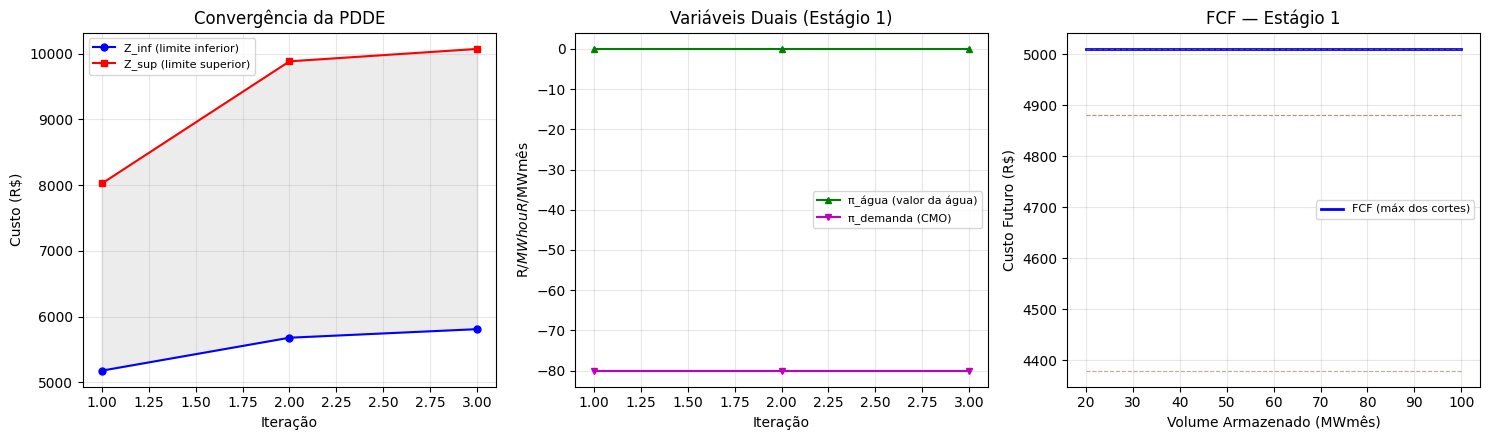

In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 4)
matplotlib.rcParams['figure.dpi'] = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Gráfico 1: Convergência Zinf vs Zsup ──
ax = axes[0]
iters = range(1, len(historico['zinf']) + 1)
ax.plot(iters, historico['zinf'], 'b-o', label='Z_inf (limite inferior)', markersize=5)
ax.plot(iters, historico['zsup'], 'r-s', label='Z_sup (limite superior)', markersize=5)
ax.fill_between(iters, historico['zinf'], historico['zsup'], alpha=0.15, color='gray')
ax.set_xlabel('Iteração')
ax.set_ylabel('Custo (R$)')
ax.set_title('Convergência da PDDE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Gráfico 2: Evolução das variáveis duais ──
ax = axes[1]
pi_aguas = [d['pi_agua_est1'] for d in historico['duais']]
cmos = [d['cmo_est1'] for d in historico['duais']]
ax.plot(iters, pi_aguas, 'g-^', label='π_água (valor da água)', markersize=5)
ax.plot(iters, cmos, 'm-v', label='π_demanda (CMO)', markersize=5)
ax.set_xlabel('Iteração')
ax.set_ylabel('R$/MWh ou R$/MWmês')
ax.set_title('Variáveis Duais (Estágio 1)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Gráfico 3: FCF do estágio 1 ──
ax = axes[2]
v_range = np.linspace(uhe.v_min, uhe.v_max, 200)
if cortes[0]:
    fcf_values = np.zeros_like(v_range)
    for i, v in enumerate(v_range):
        fcf_values[i] = max(c.pi * v + c.delta for c in cortes[0])
        fcf_values[i] = max(0, fcf_values[i])
    ax.plot(v_range, fcf_values, 'b-', linewidth=2, label='FCF (máx dos cortes)')
    # Mostrar cortes individuais
    for k, corte in enumerate(cortes[0][:8]):
        y_corte = corte.pi * v_range + corte.delta
        ax.plot(v_range, y_corte, '--', alpha=0.4, linewidth=0.8)
ax.set_xlabel('Volume Armazenado (MWmês)')
ax.set_ylabel('Custo Futuro (R$)')
ax.set_title('FCF — Estágio 1')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/pdde_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos salvos!")

## 7. Simulação Final: Operação Ótima com FCF Convergida

Agora usamos a FCF convergida para simular a operação com um cenário específico e analisar as variáveis duais em detalhe.

In [ ]:
print("="*70)
print("SIMULAÇÃO FINAL — Operação com FCF convergida")
print("="*70)

# Cenário determinístico (afluências médias)
v_atual = uhe.v_ini
resultados_finais = []

for t in range(N_ESTAGIOS):
    afl = afluencia_media[t]
    res = resolver_estagio(
        v_ant=v_atual,
        afluencia=afl,
        t=t,
        cortes_futuro=cortes[t],
        verbose=False
    )
    resultados_finais.append(res)
    v_atual = res['v_final']

# Tabela de resultados
print(f"\n{'Estágio':<10} {'Afluen.':<8} {'Turbin.':<8} {'Vert.':<8} "
      f"{'GT1':<8} {'GT2':<8} {'Déficit':<8} {'V_final':<8} "
      f"{'Custo$':<10} {'π_água':<10} {'CMO':<10}")
print("-" * 100)

for t in range(N_ESTAGIOS):
    r = resultados_finais[t]
    print(f"{t+1:<10} {afluencia_media[t]:<8.1f} {r['q']:<8.1f} {r['s']:<8.1f} "
          f"{r['gt1']:<8.1f} {r['gt2']:<8.1f} {r['deficit']:<8.1f} {r['v_final']:<8.1f} "
          f"{r['custo_imediato']:<10.1f} {r['pi_agua']:<10.2f} {r['pi_demanda']:<10.2f}")

In [ ]:
print("\n" + "="*70)
print("INTERPRETAÇÃO DAS VARIÁVEIS DUAIS")
print("="*70)

for t in range(N_ESTAGIOS):
    r = resultados_finais[t]
    print(f"\n── Estágio {t+1} ──")
    print(f"  π_água = {r['pi_agua']:.2f} R$/MWmês")
    if r['pi_agua'] < 0:
        print(f"    → Sinal negativo: cada MWmês adicional armazenado")
        print(f"      REDUZIRIA o custo total em {abs(r['pi_agua']):.2f} R$")
        print(f"    → Água tem valor econômico: vale a pena armazenar")
    elif r['pi_agua'] == 0:
        print(f"    → Valor zero: reservatório está em nível confortável")
        print(f"    → Marginalidade da água é nula neste ponto")
    else:
        print(f"    → Sinal positivo: excesso de água, reservatório no limite")

    print(f"\n  π_demanda (CMO) = {r['pi_demanda']:.2f} R$/MWh")
    if r['pi_demanda'] <= utes[0].custo:
        print(f"    → CMO <= custo da UTE Barata ({utes[0].custo} R$): "
              f"demanda atendida majoritariamente por hidro")
    elif r['pi_demanda'] <= utes[1].custo:
        print(f"    → CMO entre custos das UTEs: UTE Barata é marginal")
        print(f"    → Preço spot seria ~{r['pi_demanda']:.0f} R$/MWh")
    else:
        print(f"    → CMO >= custo da UTE Cara ({utes[1].custo} R$): "
              f"sistema estressado!")
        print(f"    → Preço spot seria ~{r['pi_demanda']:.0f} R$/MWh")

## 8. Visualização da Operação

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

estagios = [1, 2, 3]

# ── Despacho por fonte ──
ax = axes[0, 0]
q_vals = [r['q'] for r in resultados_finais]
gt1_vals = [r['gt1'] for r in resultados_finais]
gt2_vals = [r['gt2'] for r in resultados_finais]
def_vals = [r['deficit'] for r in resultados_finais]

bottom = np.zeros(3)
ax.bar(estagios, q_vals, label='Hidro (q)', color='#2196F3')
bottom += q_vals
ax.bar(estagios, gt1_vals, bottom=bottom, label=f'UTE Barata ({utes[0].custo}R$)', color='#FF9800')
bottom += gt1_vals
ax.bar(estagios, gt2_vals, bottom=bottom, label=f'UTE Cara ({utes[1].custo}R$)', color='#F44336')
bottom += gt2_vals
if max(def_vals) > 0.01:
    ax.bar(estagios, def_vals, bottom=bottom, label='Déficit', color='#9C27B0')
ax.plot(estagios, demanda, 'k--o', label='Demanda', linewidth=2)
ax.set_xlabel('Estágio')
ax.set_ylabel('MWmed')
ax.set_title('Despacho por Fonte')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Volume do reservatório ──
ax = axes[0, 1]
v_vals = [uhe.v_ini] + [r['v_final'] for r in resultados_finais]
ax.plot([0, 1, 2, 3], v_vals, 'b-o', linewidth=2, markersize=8, label='Volume')
ax.axhline(y=uhe.v_max, color='r', linestyle='--', alpha=0.5, label=f'V_max={uhe.v_max}')
ax.axhline(y=uhe.v_min, color='orange', linestyle='--', alpha=0.5, label=f'V_min={uhe.v_min}')
ax.fill_between([0, 1, 2, 3], uhe.v_min, v_vals, alpha=0.2, color='blue')
ax.set_xlabel('Estágio (0=inicial)')
ax.set_ylabel('Volume (MWmês)')
ax.set_title('Trajetória do Reservatório')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, uhe.v_max * 1.1)

# ── Variáveis duais: valor da água ──
ax = axes[1, 0]
pi_aguas = [r['pi_agua'] for r in resultados_finais]
colors = ['green' if p <= 0 else 'red' for p in pi_aguas]
bars = ax.bar(estagios, [abs(p) for p in pi_aguas], color=colors, alpha=0.7, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, pi_aguas)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Estágio')
ax.set_ylabel('|π_água| (R$/MWmês)')
ax.set_title('Valor da Água (π_água)\nVerde: água valiosa | Vermelho: excesso')
ax.grid(True, alpha=0.3)

# ── CMO ──
ax = axes[1, 1]
cmos_finais = [r['pi_demanda'] for r in resultados_finais]
ax.bar(estagios, cmos_finais, color='#7B1FA2', alpha=0.7, edgecolor='black')
ax.axhline(y=utes[0].custo, color='orange', linestyle='--',
           label=f'Custo UTE Barata ({utes[0].custo})', alpha=0.7)
ax.axhline(y=utes[1].custo, color='red', linestyle='--',
           label=f'Custo UTE Cara ({utes[1].custo})', alpha=0.7)
for i, val in enumerate(cmos_finais):
    ax.text(estagios[i], val + 5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Estágio')
ax.set_ylabel('CMO (R$/MWh)')
ax.set_title('Custo Marginal de Operação (CMO)\n= Variável dual da demanda')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/pdde_operacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos da operação salvos!")

## 9. Análise de Sensibilidade: O que acontece se a afluência cai?

Vamos simular um cenário "seco" para ver como as duais reagem.

In [ ]:
print("Comparação: Cenário Normal vs Cenário Seco")
print("="*70)

cenarios = {
    'Normal (afl. média)': afluencia_media,
    'Seco (50% da média)': [a * 0.5 for a in afluencia_media],
    'Muito seco (20%)': [a * 0.2 for a in afluencia_media],
}

for nome, afluencias in cenarios.items():
    v_atual = uhe.v_ini
    custo_total = 0
    print(f"\n── {nome}: afluências = {[f'{a:.0f}' for a in afluencias]} ──")

    for t in range(N_ESTAGIOS):
        res = resolver_estagio(
            v_ant=v_atual, afluencia=afluencias[t], t=t,
            cortes_futuro=cortes[t], verbose=False
        )
        custo_total += res['custo_imediato']
        print(f"  Est.{t+1}: q={res['q']:.0f} gt1={res['gt1']:.0f} gt2={res['gt2']:.0f} "
              f"def={res['deficit']:.0f} v={res['v_final']:.0f} | "
              f"π_água={res['pi_agua']:.0f} CMO={res['pi_demanda']:.0f}")
        v_atual = res['v_final']

    print(f"  → Custo total: {custo_total:.0f} R$")

## 10. Resumo: O que Aprendemos

### Forward
- Simula cenários do presente ao futuro, usando ruídos aleatórios para gerar afluências
- Usa a FCF atual para tomar decisões ótimas em cada estágio
- Produz o **limite superior** (Z_sup) e os **estados visitados** (volumes)

### Backward  
- Percorre do futuro ao presente, construindo **cortes de Benders**
- Para cada estado visitado, gera aberturas com **ruídos independentes**
- Extrai as **variáveis duais** (π_água) de cada subproblema
- O corte é a média: `α ≥ E[π_água] · v + δ`

### Variáveis Duais
- **π_água**: valor marginal da água armazenada. Quanto o custo diminui se tivermos +1 MWmês no reservatório
- **π_demanda (CMO)**: custo de atender +1 MWmed de carga. Base do preço de energia (PLD)
- Quando reservatórios estão baixos → π_água sobe → CMO sobe → preços altos
- As duais são exatamente os coeficientes dos cortes de Benders!

### Ruídos
- No **Forward**: geram cenários completos (séries sintéticas)
- No **Backward**: geram leques de possibilidades (aberturas locais)
- São **independentes** entre Forward e Backward